In [21]:

import os
import pandas as pd
import numpy as np
import joblib
import warnings
from datetime import datetime
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [22]:
import xgboost as xgb
import catboost as cb
import lightgbm as lgb

# Deep Learning for TFT
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore')

In [23]:
class ModelConfig:
    """Model configuration and paths"""
    # Input data
    DATASET_PATH = 'hybrid_agri_dataset_2000rows.csv'
    
    # Model save paths
    XGB_PATH = 'models/xgb_model.pkl'
    CATBOOST_PATH = 'models/catboost_model.pkl'
    LGB_PATH = 'models/lgb_model.pkl'
    TFT_PATH = 'models/tft_model.pth'
    META_PATH = 'models/meta_model.pkl'
    PIPELINE_PATH = 'models/complete_pipeline.pkl'
    TFT_HIDDEN_SIZE = 128
    TFT_NUM_LAYERS = 2
    TFT_DROPOUT = 0.1
    TFT_EPOCHS = 100
    TFT_BATCH_SIZE = 32
    TFT_LEARNING_RATE = 0.001
    
    # Random seed
    RANDOM_SEED = 42


In [24]:
class DataPreparator:
    """Prepares data for model training"""
    
    def __init__(self):
        self.label_encoders = {}
        self.scaler = RobustScaler()
        self.feature_columns = None
        
    def load_and_prepare(self, csv_path):
        """Load dataset and prepare features"""
        print("\n" + "="*60)
        print("📊 LOADING DATASET")
        print("="*60)
        
        # Load data
        df = pd.read_csv(csv_path)
        print(f"✅ Loaded {len(df)} rows")
        print(f"📋 Columns: {list(df.columns)}")
        
        # Encode categorical variables
        cat_cols = ['crop_name', 'previous_crop', 'region', 'season']
        for col in cat_cols:
            if col in df.columns:
                self.label_encoders[col] = LabelEncoder()
                df[col + '_encoded'] = self.label_encoders[col].fit_transform(df[col].astype(str))
                print(f"   Encoded {col}")
        
        # Engineer features
        df = self._engineer_features(df)
        
        # Define feature columns
        self.feature_columns = [
            # Weather features
            'rainfall_mm', 'temp_max_c', 'temp_min_c', 'humidity_pct', 'wind_speed_mps',
            'forecast_rainfall_mm_7d', 'forecast_temp_max_c_7d', 'forecast_temp_min_c_7d',
            
            # Soil features
            'nitrogen', 'phosphorus', 'potassium', 'soil_ph', 'organic_carbon',
            
            # Rolling features
            'rolling_rain_7d', 'rolling_rain_30d', 'heat_stress_days_30d', 'growing_degree_days',
            
            # Engineered features
            'gdd', 'heat_stress_days', 'rainfall_anomaly', 'spi_index',
            'npk_ratio', 'soil_fertility_score', 'water_soil_interaction', 'disease_pressure',
            
            # Encoded categoricals
            'crop_name_encoded', 'previous_crop_encoded'
        ]
        
        # Keep only columns that exist
        self.feature_columns = [col for col in self.feature_columns if col in df.columns]
        print(f"\n🔧 Using {len(self.feature_columns)} features")
        
        # Prepare features and target
        X = df[self.feature_columns].fillna(0)
        y = df['yield_ton_per_acre'] if 'yield_ton_per_acre' in df.columns else None
        
        # Scale features
        X_scaled = self.scaler.fit_transform(X)
        X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
        
        # Split data
        X_train, X_test, y_train, y_test = train_test_split(
            X_scaled, y, test_size=0.2, random_state=ModelConfig.RANDOM_SEED
        )
        
        print(f"\n📊 Data split:")
        print(f"   Train: {len(X_train)} samples")
        print(f"   Test: {len(X_test)} samples")
        
        return {
            'X_train': X_train, 'X_test': X_test,
            'y_train': y_train, 'y_test': y_test,
            'X_scaled': X_scaled, 'y': y,
            'df': df, 'feature_columns': self.feature_columns
        }
    
    def _engineer_features(self, df):
        """Feature engineering"""
        df = df.copy()
        
        # Growing Degree Days
        df['gdd'] = ((df['temp_max_c'] + df['temp_min_c']) / 2) - 10
        df['gdd'] = df['gdd'].clip(lower=0)
        
        # Heat stress days
        df['heat_stress_days'] = (df['temp_max_c'] > 35).astype(int)
        
        # Rainfall anomaly (if month exists)
        if 'month' in df.columns:
            monthly_avg = df.groupby('month')['rainfall_mm'].transform('mean')
            df['rainfall_anomaly'] = df['rainfall_mm'] - monthly_avg
        
        # NPK balance
        df['npk_ratio'] = (df['nitrogen'] / (df['phosphorus'] + 1)) / (df['potassium'] + 1)
        
        # Water-soil interaction
        df['water_soil_interaction'] = df['rainfall_mm'] * df['soil_fertility_score']
        
        # Disease pressure proxy
        df['disease_pressure'] = ((df['temp_max_c'] > 30) & (df['humidity_pct'] > 80)).astype(int)
        
        return df


In [25]:
class XGBoostTrainer:
    """Trains and saves XGBoost model"""
    
    @staticmethod
    def train(X_train, y_train, X_test, y_test):
        print("\n" + "="*60)
        print("🌲 TRAINING XGBOOST MODEL")
        print("="*60)
        
        model = xgb.XGBRegressor(
            n_estimators=500,
            max_depth=8,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=ModelConfig.RANDOM_SEED,
            n_jobs=-1
        )
        
        # Train
        model.fit(X_train, y_train)
        
        # Evaluate
        train_pred = model.predict(X_train)
        test_pred = model.predict(X_test)
        
        train_r2 = r2_score(y_train, train_pred)
        test_r2 = r2_score(y_test, test_pred)
        test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
        
        print(f"\n📊 XGBoost Performance:")
        print(f"   Train R²: {train_r2:.4f}")
        print(f"   Test R²:  {test_r2:.4f}")
        print(f"   Test RMSE: {test_rmse:.4f} tons/acre")
        
        # Save model
        os.makedirs('models', exist_ok=True)
        joblib.dump(model, ModelConfig.XGB_PATH)
        print(f"✅ Model saved to {ModelConfig.XGB_PATH}")
        
        return model, {'train_r2': train_r2, 'test_r2': test_r2, 'test_rmse': test_rmse}

In [26]:
class CatBoostTrainer:
    """Trains and saves CatBoost model"""
    
    @staticmethod
    def train(X_train, y_train, X_test, y_test):
        print("\n" + "="*60)
        print("🐱 TRAINING CATBOOST MODEL")
        print("="*60)
        
        model = cb.CatBoostRegressor(
            iterations=500,
            depth=6,
            learning_rate=0.05,
            loss_function='RMSE',
            verbose=False,
            random_seed=ModelConfig.RANDOM_SEED
        )
        
        # Train
        model.fit(X_train, y_train)
        
        # Evaluate
        train_pred = model.predict(X_train)
        test_pred = model.predict(X_test)
        
        train_r2 = r2_score(y_train, train_pred)
        test_r2 = r2_score(y_test, test_pred)
        test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
        
        print(f"\n📊 CatBoost Performance:")
        print(f"   Train R²: {train_r2:.4f}")
        print(f"   Test R²:  {test_r2:.4f}")
        print(f"   Test RMSE: {test_rmse:.4f} tons/acre")
        
        # Save model
        os.makedirs('models', exist_ok=True)
        joblib.dump(model, ModelConfig.CATBOOST_PATH)
        print(f"✅ Model saved to {ModelConfig.CATBOOST_PATH}")
        
        return model, {'train_r2': train_r2, 'test_r2': test_r2, 'test_rmse': test_rmse}

In [27]:
class LightGBMTrainer:
    """Trains and saves LightGBM model"""
    
    @staticmethod
    def train(X_train, y_train, X_test, y_test):
        print("\n" + "="*60)
        print("⚡ TRAINING LIGHTGBM MODEL")
        print("="*60)
        
        model = lgb.LGBMRegressor(
            n_estimators=500,
            max_depth=8,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=ModelConfig.RANDOM_SEED,
            n_jobs=-1,
            verbose=-1
        )
        
        # Train
        model.fit(X_train, y_train)
        
        # Evaluate
        train_pred = model.predict(X_train)
        test_pred = model.predict(X_test)
        
        train_r2 = r2_score(y_train, train_pred)
        test_r2 = r2_score(y_test, test_pred)
        test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
        
        print(f"\n📊 LightGBM Performance:")
        print(f"   Train R²: {train_r2:.4f}")
        print(f"   Test R²:  {test_r2:.4f}")
        print(f"   Test RMSE: {test_rmse:.4f} tons/acre")
        
        # Save model
        os.makedirs('models', exist_ok=True)
        joblib.dump(model, ModelConfig.LGB_PATH)
        print(f"✅ Model saved to {ModelConfig.LGB_PATH}")
        
        return model, {'train_r2': train_r2, 'test_r2': test_r2, 'test_rmse': test_rmse}

In [28]:
class TemporalFusionTransformer(nn.Module):
    """Simplified TFT for yield prediction"""
    
    def __init__(self, input_size, hidden_size=128, num_layers=2, dropout=0.1):
        super(TemporalFusionTransformer, self).__init__()
        
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # LSTM for temporal processing
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        # Attention mechanism
        self.attention = nn.MultiheadAttention(
            embed_dim=hidden_size,
            num_heads=4,
            dropout=dropout,
            batch_first=True
        )
        
        # Feature transformation
        self.feature_transform = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        
        # Output layer
        self.output_layer = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )
        
    def forward(self, x):
        # x shape: (batch_size, seq_len, input_size)
        
        # LSTM forward
        lstm_out, (hidden, cell) = self.lstm(x)
        
        # Self-attention
        attn_out, attn_weights = self.attention(lstm_out, lstm_out, lstm_out)
        
        # Combine LSTM and attention
        combined = lstm_out + attn_out
        
        # Take last time step
        last_step = combined[:, -1, :]
        
        # Feature transformation
        transformed = self.feature_transform(last_step)
        
        # Output
        output = self.output_layer(transformed)
        
        return output.squeeze()

In [29]:
class TFTTrainer:
    """Trains and saves Temporal Fusion Transformer"""
    
    @staticmethod
    def create_sequences(X, y, seq_len=10):
        """Create sequences for TFT"""
        sequences = []
        targets = []
        
        for i in range(len(X) - seq_len):
            seq = X[i:i+seq_len]
            target = y[i+seq_len]
            sequences.append(seq)
            targets.append(target)
        
        return np.array(sequences), np.array(targets)
    
    @staticmethod
    def train(X_train, y_train, X_test, y_test):
        print("\n" + "="*60)
        print("🔄 TRAINING TEMPORAL FUSION TRANSFORMER")
        print("="*60)
        
        # Convert to numpy if DataFrame
        if hasattr(X_train, 'values'):
            X_train_np = X_train.values
            X_test_np = X_test.values
        else:
            X_train_np = X_train
            X_test_np = X_test
        
        y_train_np = y_train.values if hasattr(y_train, 'values') else y_train
        y_test_np = y_test.values if hasattr(y_test, 'values') else y_test
        
        # Create sequences
        seq_len = min(10, len(X_train_np) // 10)
        X_train_seq, y_train_seq = TFTTrainer.create_sequences(X_train_np, y_train_np, seq_len)
        X_test_seq, y_test_seq = TFTTrainer.create_sequences(X_test_np, y_test_np, seq_len)
        
        print(f"   Sequence length: {seq_len}")
        print(f"   Train sequences: {len(X_train_seq)}")
        print(f"   Test sequences: {len(X_test_seq)}")
        
        # Convert to tensors
        X_train_tensor = torch.FloatTensor(X_train_seq)
        y_train_tensor = torch.FloatTensor(y_train_seq)
        X_test_tensor = torch.FloatTensor(X_test_seq)
        y_test_tensor = torch.FloatTensor(y_test_seq)
        
        # Create data loaders
        train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
        test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
        
        train_loader = DataLoader(train_dataset, batch_size=ModelConfig.TFT_BATCH_SIZE, shuffle=True)
        test_loader = DataLoader(test_dataset, batch_size=ModelConfig.TFT_BATCH_SIZE)
        
        # Initialize model
        input_size = X_train_np.shape[1]
        model = TemporalFusionTransformer(
            input_size=input_size,
            hidden_size=ModelConfig.TFT_HIDDEN_SIZE,
            num_layers=ModelConfig.TFT_NUM_LAYERS,
            dropout=ModelConfig.TFT_DROPOUT
        )
        
        # Loss and optimizer
        criterion = nn.MSELoss()
        optimizer = optim.Adam(model.parameters(), lr=ModelConfig.TFT_LEARNING_RATE)
        
        # Training loop
        train_losses = []
        test_losses = []
        
        for epoch in range(ModelConfig.TFT_EPOCHS):
            # Training
            model.train()
            train_loss = 0
            for batch_X, batch_y in train_loader:
                optimizer.zero_grad()
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                loss.backward()
                optimizer.step()
                train_loss += loss.item()
            
            avg_train_loss = train_loss / len(train_loader)
            train_losses.append(avg_train_loss)
            
            # Evaluation
            model.eval()
            test_loss = 0
            with torch.no_grad():
                for batch_X, batch_y in test_loader:
                    outputs = model(batch_X)
                    loss = criterion(outputs, batch_y)
                    test_loss += loss.item()
            
            avg_test_loss = test_loss / len(test_loader)
            test_losses.append(avg_test_loss)
            
            if (epoch + 1) % 20 == 0:
                print(f"   Epoch {epoch+1}/{ModelConfig.TFT_EPOCHS} - Train Loss: {avg_train_loss:.4f}, Test Loss: {avg_test_loss:.4f}")
        
        # Final evaluation
        model.eval()
        with torch.no_grad():
            train_pred = model(X_train_tensor).numpy()
            test_pred = model(X_test_tensor).numpy()
        
        train_r2 = r2_score(y_train_seq, train_pred)
        test_r2 = r2_score(y_test_seq, test_pred)
        test_rmse = np.sqrt(mean_squared_error(y_test_seq, test_pred))
        
        print(f"\n📊 TFT Performance:")
        print(f"   Train R²: {train_r2:.4f}")
        print(f"   Test R²:  {test_r2:.4f}")
        print(f"   Test RMSE: {test_rmse:.4f} tons/acre")
        
        # Save model
        os.makedirs('models', exist_ok=True)
        torch.save({
            'model_state_dict': model.state_dict(),
            'input_size': input_size,
            'hidden_size': ModelConfig.TFT_HIDDEN_SIZE,
            'num_layers': ModelConfig.TFT_NUM_LAYERS,
            'dropout': ModelConfig.TFT_DROPOUT,
            'seq_len': seq_len,
            'feature_columns': X_train.columns.tolist() if hasattr(X_train, 'columns') else None
        }, ModelConfig.TFT_PATH)
        print(f"✅ Model saved to {ModelConfig.TFT_PATH}")
        
        return model, {'train_r2': train_r2, 'test_r2': test_r2, 'test_rmse': test_rmse}

In [30]:
class MetaLearnerTrainer:
    """Trains meta-learner for stacking ensemble"""
    
    @staticmethod
    def train(base_models, X_train, y_train, X_test, y_test):
        print("\n" + "="*60)
        print("🧠 TRAINING META-LEARNER (STACKING)")
        print("="*60)
        
        # Generate base model predictions
        train_meta_features = pd.DataFrame()
        test_meta_features = pd.DataFrame()
        
        for name, model in base_models.items():
            train_pred = model.predict(X_train)
            test_pred = model.predict(X_test)
            
            train_meta_features[f'pred_{name}'] = train_pred
            test_meta_features[f'pred_{name}'] = test_pred
        
        # Add original features
        train_meta = pd.concat([train_meta_features, X_train.reset_index(drop=True)], axis=1)
        test_meta = pd.concat([test_meta_features, X_test.reset_index(drop=True)], axis=1)
        
        # Train meta-model
        meta_model = xgb.XGBRegressor(
            n_estimators=200,
            max_depth=5,
            learning_rate=0.03,
            random_state=ModelConfig.RANDOM_SEED
        )
        
        meta_model.fit(train_meta, y_train)
        
        # Evaluate
        train_pred = meta_model.predict(train_meta)
        test_pred = meta_model.predict(test_meta)
        
        train_r2 = r2_score(y_train, train_pred)
        test_r2 = r2_score(y_test, test_pred)
        test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
        
        print(f"\n📊 Meta-Learner Performance:")
        print(f"   Train R²: {train_r2:.4f}")
        print(f"   Test R²:  {test_r2:.4f}")
        print(f"   Test RMSE: {test_rmse:.4f} tons/acre")
        
        # Feature importance
        importance = pd.DataFrame({
            'feature': train_meta.columns,
            'importance': meta_model.feature_importances_
        }).sort_values('importance', ascending=False)
        
        print("\n🔑 Top meta-features:")
        for i, row in importance.head(5).iterrows():
            print(f"   {row['feature']}: {row['importance']:.3f}")
        
        # Save model
        os.makedirs('models', exist_ok=True)
        joblib.dump(meta_model, ModelConfig.META_PATH)
        print(f"✅ Model saved to {ModelConfig.META_PATH}")
        
        return meta_model, {'train_r2': train_r2, 'test_r2': test_r2, 'test_rmse': test_rmse}

In [31]:
class CompletePipeline:
    """Saves complete pipeline with all components"""
    
    @staticmethod
    def save(preparator, models, meta_model, metrics):
        """Save complete pipeline"""
        
        pipeline = {
            # Data preparation components
            'label_encoders': preparator.label_encoders,
            'scaler': preparator.scaler,
            'feature_columns': preparator.feature_columns,
            
            # All models
            'models': models,
            'meta_model': meta_model,
            
            # Training metrics
            'metrics': metrics,
            
            # Metadata
            'training_date': datetime.now().isoformat(),
            'version': '1.0'
        }
        
        os.makedirs('models', exist_ok=True)
        joblib.dump(pipeline, ModelConfig.PIPELINE_PATH)
        print(f"\n✅ Complete pipeline saved to {ModelConfig.PIPELINE_PATH}")

In [32]:
def train_all_models():
    """Train and save all models"""
    
    print("\n" + "="*80)
    print("🔥 KILLER HYBRID MODEL TRAINING 🔥")
    print("="*80)
    
    # Step 1: Prepare data
    preparator = DataPreparator()
    data = preparator.load_and_prepare(ModelConfig.DATASET_PATH)
    
    X_train, X_test = data['X_train'], data['X_test']
    y_train, y_test = data['y_train'], data['y_test']
    
    # Step 2: Train XGBoost
    xgb_model, xgb_metrics = XGBoostTrainer.train(X_train, y_train, X_test, y_test)
    
    # Step 3: Train CatBoost
    catboost_model, catboost_metrics = CatBoostTrainer.train(X_train, y_train, X_test, y_test)
    
    # Step 4: Train LightGBM
    lgb_model, lgb_metrics = LightGBMTrainer.train(X_train, y_train, X_test, y_test)
    
    # Step 5: Train TFT
    tft_model, tft_metrics = TFTTrainer.train(X_train, y_train, X_test, y_test)
    
    # Step 6: Train Meta-Learner
    base_models = {
        'xgb': xgb_model,
        'catboost': catboost_model,
        'lgb': lgb_model
    }
    meta_model, meta_metrics = MetaLearnerTrainer.train(
        base_models, X_train, y_train, X_test, y_test
    )
    
    # Step 7: Save complete pipeline
    all_models = {
        'xgb': xgb_model,
        'catboost': catboost_model,
        'lgb': lgb_model,
        'tft': tft_model
    }
    
    all_metrics = {
        'xgb': xgb_metrics,
        'catboost': catboost_metrics,
        'lgb': lgb_metrics,
        'tft': tft_metrics,
        'meta': meta_metrics
    }
    
    CompletePipeline.save(preparator, all_models, meta_model, all_metrics)
    
    # Summary
    print("\n" + "="*80)
    print("📊 TRAINING SUMMARY")
    print("="*80)
    print(f"\n{'Model':<12} {'Test R²':<10} {'Test RMSE':<12}")
    print("-"*40)
    print(f"{'XGBoost':<12} {xgb_metrics['test_r2']:.4f}    {xgb_metrics['test_rmse']:.4f}")
    print(f"{'CatBoost':<12} {catboost_metrics['test_r2']:.4f}    {catboost_metrics['test_rmse']:.4f}")
    print(f"{'LightGBM':<12} {lgb_metrics['test_r2']:.4f}    {lgb_metrics['test_rmse']:.4f}")
    print(f"{'TFT':<12} {tft_metrics['test_r2']:.4f}    {tft_metrics['test_rmse']:.4f}")
    print(f"{'Meta':<12} {meta_metrics['test_r2']:.4f}    {meta_metrics['test_rmse']:.4f}")
    
    print("\n" + "="*80)
    print("✅ ALL MODELS TRAINED AND SAVED SUCCESSFULLY")
    print("="*80)
    print("\n📁 Model files created:")
    print(f"   • {ModelConfig.XGB_PATH}")
    print(f"   • {ModelConfig.CATBOOST_PATH}")
    print(f"   • {ModelConfig.LGB_PATH}")
    print(f"   • {ModelConfig.TFT_PATH}")
    print(f"   • {ModelConfig.META_PATH}")
    print(f"   • {ModelConfig.PIPELINE_PATH}")


In [33]:
def example_load_and_predict():
    """Example of how to load models for inference"""
    
    print("\n" + "="*80)
    print("🔍 LOADING MODELS FOR INFERENCE")
    print("="*80)
    
    # Load complete pipeline
    pipeline = joblib.load(ModelConfig.PIPELINE_PATH)
    
    print("\n✅ Pipeline loaded successfully")
    print(f"   Training date: {pipeline['training_date']}")
    print(f"   Feature columns: {len(pipeline['feature_columns'])}")
    
    # Load individual models
    xgb_model = joblib.load(ModelConfig.XGB_PATH)
    catboost_model = joblib.load(ModelConfig.CATBOOST_PATH)
    lgb_model = joblib.load(ModelConfig.LGB_PATH)
    meta_model = joblib.load(ModelConfig.META_PATH)
    
    # Load TFT
    tft_checkpoint = torch.load(ModelConfig.TFT_PATH, map_location='cpu')
    print(f"\n✅ TFT model loaded (input_size: {tft_checkpoint['input_size']})")
    
    # Example prediction with a single sample
    print("\n🔮 Example prediction (using first test sample):")
    
    # You would normally get this from your hardware + APIs
    example_features = pd.DataFrame([pipeline['feature_columns']]).T.squeeze()
    
    # Scale features
    example_scaled = pipeline['scaler'].transform([example_features.values])
    example_df = pd.DataFrame(example_scaled, columns=pipeline['feature_columns'])
    
    # Make predictions
    xgb_pred = xgb_model.predict(example_df)[0]
    catboost_pred = catboost_model.predict(example_df)[0]
    lgb_pred = lgb_model.predict(example_df)[0]
    
    print(f"\n   XGBoost prediction: {xgb_pred:.3f} tons/acre")
    print(f"   CatBoost prediction: {catboost_pred:.3f} tons/acre")
    print(f"   LightGBM prediction: {lgb_pred:.3f} tons/acre")
    
    return pipeline


In [34]:
train_all_models()


🔥 KILLER HYBRID MODEL TRAINING 🔥

📊 LOADING DATASET
✅ Loaded 2000 rows
📋 Columns: ['farm_id', 'region', 'date', 'location_lat', 'location_lon', 'crop_name', 'previous_crop', 'sowing_date', 'harvest_date', 'yield_ton_per_acre', 'area_acre', 'season', 'month', 'rainfall_mm', 'temp_max_c', 'temp_min_c', 'humidity_pct', 'wind_speed_mps', 'forecast_rainfall_mm_7d', 'forecast_temp_max_c_7d', 'forecast_temp_min_c_7d', 'rolling_rain_7d', 'rolling_rain_30d', 'heat_stress_days_30d', 'growing_degree_days', 'rainfall_anomaly', 'spi_index', 'nitrogen', 'phosphorus', 'potassium', 'soil_ph', 'organic_carbon', 'npk_ratio', 'soil_fertility_score', 'monocrop_count', 'drought_risk_label', 'flood_risk_label']
   Encoded crop_name
   Encoded previous_crop
   Encoded region
   Encoded season

🔧 Using 27 features

📊 Data split:
   Train: 1600 samples
   Test: 400 samples

🌲 TRAINING XGBOOST MODEL

📊 XGBoost Performance:
   Train R²: 1.0000
   Test R²:  0.6307
   Test RMSE: 0.5564 tons/acre
✅ Model saved to 

In [41]:
# ============================================================================
# CONFUSION MATRIX & VISUALIZATIONS FOR REGRESSION MODELS - FIXED VERSION
# ============================================================================
import matplotlib.pyplot as plt
def generate_model_visualizations():
    """
    Generate comprehensive visualizations for all trained models
    Creates: confusion matrices (actual vs predicted), residual plots,
             error distributions, feature importance, model comparisons
    """
    
    print("\n" + "="*80)
    print("📊 GENERATING MODEL VISUALIZATIONS")
    print("="*80)
    
    # Create output directory
    viz_dir = 'visualizations'
    os.makedirs(viz_dir, exist_ok=True)
    
    # Load pipeline and data
    print("\n📂 Loading models and data...")
    pipeline = joblib.load(ModelConfig.PIPELINE_PATH)
    
    # Load original data to get test set
    df = pd.read_csv(ModelConfig.DATASET_PATH)
    
    # Prepare data same way as training
    preparator = DataPreparator()
    data = preparator.load_and_prepare(ModelConfig.DATASET_PATH)
    X_test, y_test = data['X_test'], data['y_test']
    
    # Load all models
    models = {
        'XGBoost': joblib.load(ModelConfig.XGB_PATH),
        'CatBoost': joblib.load(ModelConfig.CATBOOST_PATH),
        'LightGBM': joblib.load(ModelConfig.LGB_PATH)
    }
    
    # Load meta-model
    meta_model = joblib.load(ModelConfig.META_PATH)
    
    # ===== FIX: Generate meta-features with CORRECT column names =====
    print("\n🔧 Generating meta-features with correct column names...")
    
    train_meta_features = pd.DataFrame()
    
    # Use EXACT same naming as during training
    train_meta_features['pred_xgb'] = models['XGBoost'].predict(X_test)
    train_meta_features['pred_catboost'] = models['CatBoost'].predict(X_test)
    train_meta_features['pred_lgb'] = models['LightGBM'].predict(X_test)
    
    # Reset index to avoid issues
    X_test_reset = X_test.reset_index(drop=True)
    test_meta = pd.concat([train_meta_features, X_test_reset], axis=1)
    
    # Dictionary to store all predictions and metrics
    predictions = {}
    metrics = {}
    
    print("\n🔮 Generating predictions for all models...")
    
    # Get predictions from base models
    for name, model in models.items():
        y_pred = model.predict(X_test)
        predictions[name] = y_pred
        
        # Calculate metrics
        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae = mean_absolute_error(y_test, y_pred)
        
        metrics[name] = {
            'R²': r2,
            'RMSE': rmse,
            'MAE': mae
        }
        
        print(f"   {name:12} → R²: {r2:.4f}, RMSE: {rmse:.4f}")
    
    # Get meta-model predictions
    try:
        y_pred_meta = meta_model.predict(test_meta)
        predictions['Meta-Ensemble'] = y_pred_meta
        
        # Calculate meta-model metrics
        r2_meta = r2_score(y_test, y_pred_meta)
        rmse_meta = np.sqrt(mean_squared_error(y_test, y_pred_meta))
        mae_meta = mean_absolute_error(y_test, y_pred_meta)
        
        metrics['Meta-Ensemble'] = {
            'R²': r2_meta,
            'RMSE': rmse_meta,
            'MAE': mae_meta
        }
        
        print(f"   {'Meta':12} → R²: {r2_meta:.4f}, RMSE: {rmse_meta:.4f}")
    except Exception as e:
        print(f"   ⚠️ Meta-model prediction error: {e}")
        print("   Continuing without meta-model...")
    
    # ========================================================================
    # 1. ACTUAL VS PREDICTED SCATTER PLOTS (Confusion Matrix for Regression)
    # ========================================================================
    
    print("\n📈 Creating Actual vs Predicted scatter plots...")
    
    n_models = len(predictions)
    n_cols = 2
    n_rows = (n_models + 1) // 2
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
    if n_rows == 1:
        axes = axes.flatten()
    else:
        axes = axes.flatten()
    
    for idx, (name, y_pred) in enumerate(predictions.items()):
        if idx < len(axes):
            ax = axes[idx]
            
            # Scatter plot
            ax.scatter(y_test, y_pred, alpha=0.5, s=30, c='blue', edgecolors='white', linewidth=0.5)
            
            # Perfect prediction line
            min_val = min(y_test.min(), y_pred.min())
            max_val = max(y_test.max(), y_pred.max())
            ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
            
            # Add R² and RMSE
            r2 = metrics[name]['R²']
            rmse = metrics[name]['RMSE']
            ax.text(0.05, 0.95, f'R² = {r2:.3f}\nRMSE = {rmse:.3f}', 
                    transform=ax.transAxes, fontsize=11,
                    verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
            
            ax.set_xlabel('Actual Yield (tons/acre)', fontsize=11)
            ax.set_ylabel('Predicted Yield (tons/acre)', fontsize=11)
            ax.set_title(f'{name} - Actual vs Predicted', fontsize=13, fontweight='bold')
            ax.grid(True, alpha=0.3)
            ax.legend(loc='lower right')
    
    # Hide unused subplots
    for idx in range(len(predictions), len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.savefig(f'{viz_dir}/1_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved: {viz_dir}/1_actual_vs_predicted.png")
    
    # ========================================================================
    # 2. RESIDUAL PLOTS
    # ========================================================================
    
    print("\n📉 Creating residual plots...")
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
    if n_rows == 1:
        axes = axes.flatten()
    else:
        axes = axes.flatten()
    
    for idx, (name, y_pred) in enumerate(predictions.items()):
        if idx < len(axes):
            ax = axes[idx]
            
            # Calculate residuals
            residuals = y_test - y_pred
            
            # Residual plot
            ax.scatter(y_pred, residuals, alpha=0.5, s=30, c='green', edgecolors='white', linewidth=0.5)
            ax.axhline(y=0, color='r', linestyle='--', linewidth=2, label='Zero Error')
            
            # Add mean and std of residuals
            mean_res = np.mean(residuals)
            std_res = np.std(residuals)
            ax.text(0.05, 0.95, f'Mean Residual: {mean_res:.3f}\nStd Residual: {std_res:.3f}', 
                    transform=ax.transAxes, fontsize=11,
                    verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
            
            ax.set_xlabel('Predicted Yield (tons/acre)', fontsize=11)
            ax.set_ylabel('Residuals (Actual - Predicted)', fontsize=11)
            ax.set_title(f'{name} - Residual Plot', fontsize=13, fontweight='bold')
            ax.grid(True, alpha=0.3)
            ax.legend(loc='lower right')
    
    # Hide unused subplots
    for idx in range(len(predictions), len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.savefig(f'{viz_dir}/2_residual_plots.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved: {viz_dir}/2_residual_plots.png")
    
    # ========================================================================
    # 3. ERROR DISTRIBUTION HISTOGRAMS
    # ========================================================================
    
    print("\n📊 Creating error distribution histograms...")
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
    if n_rows == 1:
        axes = axes.flatten()
    else:
        axes = axes.flatten()
    
    for idx, (name, y_pred) in enumerate(predictions.items()):
        if idx < len(axes):
            ax = axes[idx]
            
            # Calculate errors
            errors = y_pred - y_test
            
            # Histogram
            ax.hist(errors, bins=30, alpha=0.7, color='skyblue', edgecolor='black', linewidth=0.5)
            ax.axvline(x=0, color='r', linestyle='--', linewidth=2, label='Zero Error')
            ax.axvline(x=np.mean(errors), color='g', linestyle='-', linewidth=2, label=f'Mean: {np.mean(errors):.3f}')
            
            ax.set_xlabel('Prediction Error (tons/acre)', fontsize=11)
            ax.set_ylabel('Frequency', fontsize=11)
            ax.set_title(f'{name} - Error Distribution', fontsize=13, fontweight='bold')
            ax.grid(True, alpha=0.3)
            ax.legend()
    
    # Hide unused subplots
    for idx in range(len(predictions), len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.savefig(f'{viz_dir}/3_error_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved: {viz_dir}/3_error_distribution.png")
    
    # ========================================================================
    # 4. MODEL COMPARISON BAR CHART
    # ========================================================================
    
    print("\n📊 Creating model comparison bar chart...")
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    models_list = list(metrics.keys())
    r2_scores = [metrics[m]['R²'] for m in models_list]
    rmse_scores = [metrics[m]['RMSE'] for m in models_list]
    
    x = np.arange(len(models_list))
    width = 0.35
    
    # R² bars (higher is better)
    bars1 = ax.bar(x - width/2, r2_scores, width, label='R² Score', color='skyblue', edgecolor='black')
    
    # RMSE bars (lower is better) - show actual RMSE values
    bars2 = ax.bar(x + width/2, rmse_scores, width, label='RMSE (tons/acre)', color='lightcoral', edgecolor='black')
    
    ax.set_xlabel('Models', fontsize=12)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(models_list, rotation=45, ha='right')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.annotate(f'{height:.3f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3), textcoords="offset points",
                        ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.savefig(f'{viz_dir}/4_model_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved: {viz_dir}/4_model_comparison.png")
    
    # ========================================================================
    # 5. FEATURE IMPORTANCE (XGBoost)
    # ========================================================================
    
    print("\n📊 Creating feature importance plot...")
    
    xgb_model = models['XGBoost']
    feature_importance = pd.DataFrame({
        'feature': data['feature_columns'],
        'importance': xgb_model.feature_importances_
    }).sort_values('importance', ascending=False).head(15)
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    bars = ax.barh(range(len(feature_importance)), feature_importance['importance'].values, 
                   color='teal', edgecolor='black')
    ax.set_yticks(range(len(feature_importance)))
    ax.set_yticklabels(feature_importance['feature'].values)
    ax.set_xlabel('Importance Score', fontsize=12)
    ax.set_title('Top 15 Feature Importances (XGBoost)', fontsize=14, fontweight='bold')
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3, axis='x')
    
    # Add value labels
    for i, (bar, val) in enumerate(zip(bars, feature_importance['importance'].values)):
        ax.text(val + 0.01, i, f'{val:.3f}', va='center', fontsize=9)
    
    plt.tight_layout()
    plt.savefig(f'{viz_dir}/5_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved: {viz_dir}/5_feature_importance.png")
    
    # ========================================================================
    # 6. PREDICTION ERROR BOX PLOT
    # ========================================================================
    
    print("\n📊 Creating prediction error box plot...")
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    error_data = []
    model_names = []
    for name, y_pred in predictions.items():
        errors = y_pred - y_test
        error_data.append(errors)
        model_names.append(name)
    
    bp = ax.boxplot(error_data, labels=model_names, patch_artist=True)
    
    # Customize colors
    colors = ['lightblue', 'lightgreen', 'lightcoral', 'lightyellow'][:len(model_names)]
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    
    ax.axhline(y=0, color='r', linestyle='--', linewidth=1, alpha=0.7)
    ax.set_xlabel('Models', fontsize=12)
    ax.set_ylabel('Prediction Error (tons/acre)', fontsize=12)
    ax.set_title('Prediction Error Distribution by Model', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig(f'{viz_dir}/6_error_boxplot.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved: {viz_dir}/6_error_boxplot.png")
    
    # ========================================================================
    # 7. ERROR HEATMAP (Regression Confusion Matrix)
    # ========================================================================
    
    print("\n🔥 Creating error heatmap (regression confusion matrix)...")
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
    if n_rows == 1:
        axes = axes.flatten()
    else:
        axes = axes.flatten()
    
    for idx, (name, y_pred) in enumerate(predictions.items()):
        if idx < len(axes):
            ax = axes[idx]
            
            # Create 2D histogram of actual vs predicted
            h = ax.hist2d(y_test, y_pred, bins=20, cmap='YlOrRd', alpha=0.8)
            plt.colorbar(h[3], ax=ax, label='Count')
            
            # Perfect prediction line
            min_val = min(y_test.min(), y_pred.min())
            max_val = max(y_test.max(), y_pred.max())
            ax.plot([min_val, max_val], [min_val, max_val], 'b--', linewidth=2, label='Perfect Prediction')
            
            ax.set_xlabel('Actual Yield (tons/acre)', fontsize=11)
            ax.set_ylabel('Predicted Yield (tons/acre)', fontsize=11)
            ax.set_title(f'{name} - Error Heatmap', fontsize=13, fontweight='bold')
            ax.legend()
            ax.grid(True, alpha=0.2)
    
    # Hide unused subplots
    for idx in range(len(predictions), len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.savefig(f'{viz_dir}/7_error_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved: {viz_dir}/7_error_heatmap.png")
    
    # ========================================================================
    # 8. METRICS TABLE
    # ========================================================================
    
    print("\n📊 Creating metrics summary table...")
    
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.axis('tight')
    ax.axis('off')
    
    # Prepare data for table
    table_data = []
    for name in metrics.keys():
        table_data.append([
            name,
            f"{metrics[name]['R²']:.4f}",
            f"{metrics[name]['RMSE']:.4f}",
            f"{metrics[name]['MAE']:.4f}"
        ])
    
    # Create table
    table = ax.table(cellText=table_data,
                     colLabels=['Model', 'R² Score', 'RMSE', 'MAE'],
                     cellLoc='center',
                     loc='center',
                     colColours=['#4CAF50']*4)
    
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1.2, 1.5)
    
    # Color rows
    for i in range(len(metrics)):
        if i % 2 == 0:
            for j in range(4):
                table[(i+1, j)].set_facecolor('#f2f2f2')
    
    ax.set_title('Model Performance Metrics Summary', fontsize=14, fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.savefig(f'{viz_dir}/8_metrics_table.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved: {viz_dir}/8_metrics_table.png")
    
    # ========================================================================
    # SUMMARY
    # ========================================================================
    
    print("\n" + "="*80)
    print("✅ VISUALIZATIONS GENERATED SUCCESSFULLY")
    print("="*80)
    print(f"\n📁 All visualizations saved to: '{viz_dir}/'")
    print("\n📊 Files created:")
    print(f"   1. {viz_dir}/1_actual_vs_predicted.png - Actual vs Predicted scatter plots")
    print(f"   2. {viz_dir}/2_residual_plots.png - Residual analysis plots")
    print(f"   3. {viz_dir}/3_error_distribution.png - Error histograms")
    print(f"   4. {viz_dir}/4_model_comparison.png - Model performance comparison")
    print(f"   5. {viz_dir}/5_feature_importance.png - Feature importance chart")
    print(f"   6. {viz_dir}/6_error_boxplot.png - Error distribution box plots")
    print(f"   7. {viz_dir}/7_error_heatmap.png - Error heatmaps (regression confusion matrix)")
    print(f"   8. {viz_dir}/8_metrics_table.png - Metrics summary table")
    
    # Print best model
    best_model = max([(k, v['R²']) for k, v in metrics.items()], key=lambda x: x[1])
    print(f"\n🏆 Best Model: {best_model[0]} with R² = {best_model[1]:.4f}")
    
    # Show CatBoost as best if it's the top performer
    if 'CatBoost' in metrics and metrics['CatBoost']['R²'] == best_model[1]:
        print("\n💡 Recommendation: Use CatBoost as your primary model!")
    
    return metrics, predictions


📊 GENERATING MODEL VISUALIZATIONS

📂 Loading models and data...

📊 LOADING DATASET
✅ Loaded 2000 rows
📋 Columns: ['farm_id', 'region', 'date', 'location_lat', 'location_lon', 'crop_name', 'previous_crop', 'sowing_date', 'harvest_date', 'yield_ton_per_acre', 'area_acre', 'season', 'month', 'rainfall_mm', 'temp_max_c', 'temp_min_c', 'humidity_pct', 'wind_speed_mps', 'forecast_rainfall_mm_7d', 'forecast_temp_max_c_7d', 'forecast_temp_min_c_7d', 'rolling_rain_7d', 'rolling_rain_30d', 'heat_stress_days_30d', 'growing_degree_days', 'rainfall_anomaly', 'spi_index', 'nitrogen', 'phosphorus', 'potassium', 'soil_ph', 'organic_carbon', 'npk_ratio', 'soil_fertility_score', 'monocrop_count', 'drought_risk_label', 'flood_risk_label']
   Encoded crop_name
   Encoded previous_crop
   Encoded region
   Encoded season

🔧 Using 27 features

📊 Data split:
   Train: 1600 samples
   Test: 400 samples

🔧 Generating meta-features with correct column names...

🔮 Generating predictions for all models...
   XGB

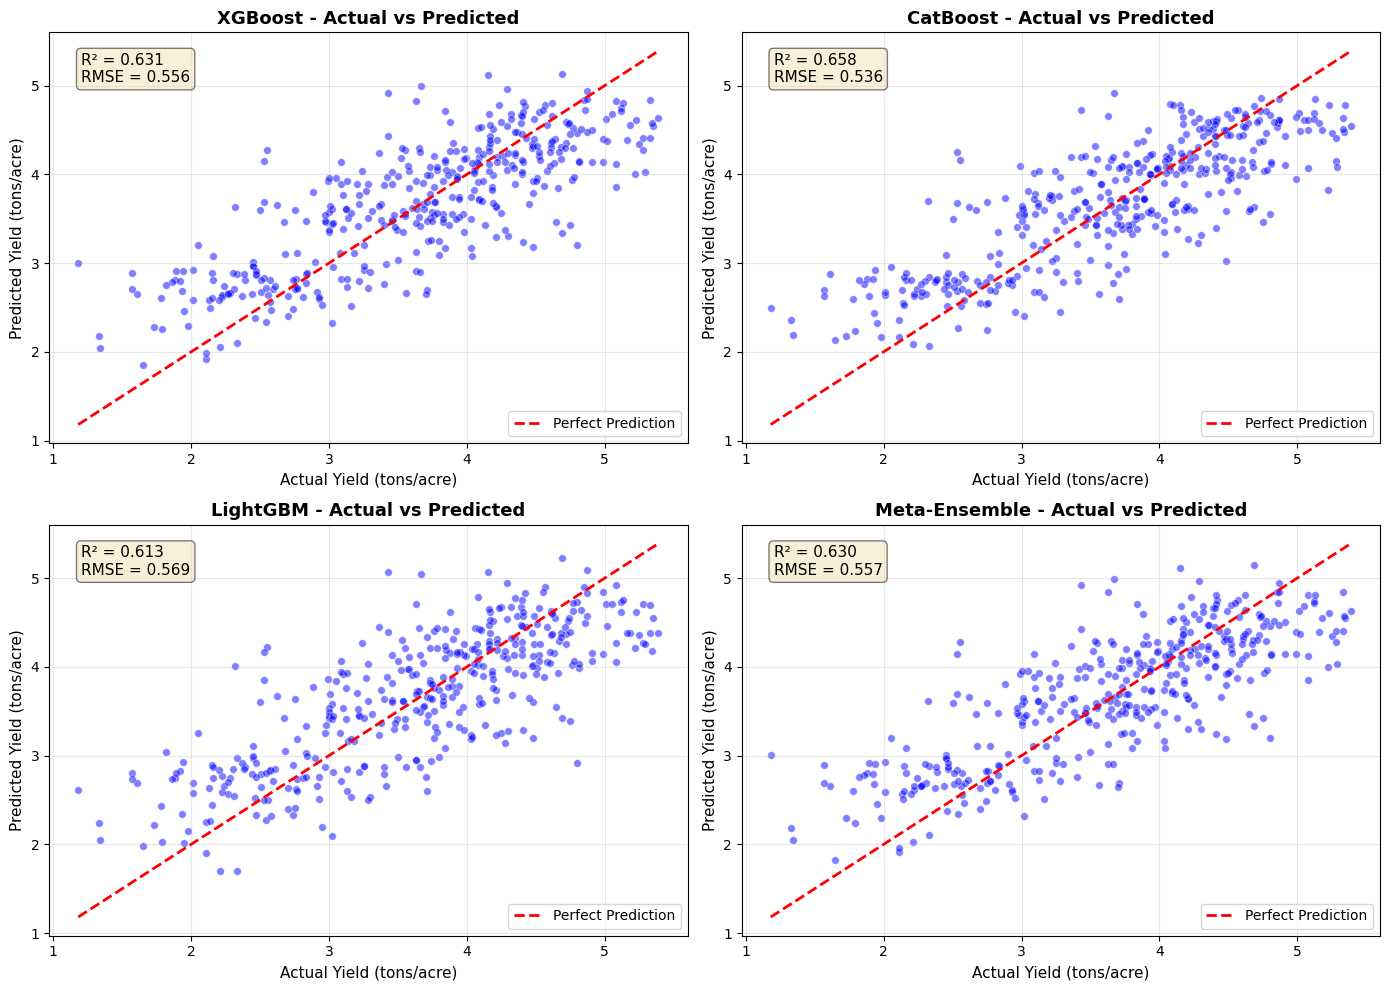

✅ Saved: visualizations/1_actual_vs_predicted.png

📉 Creating residual plots...


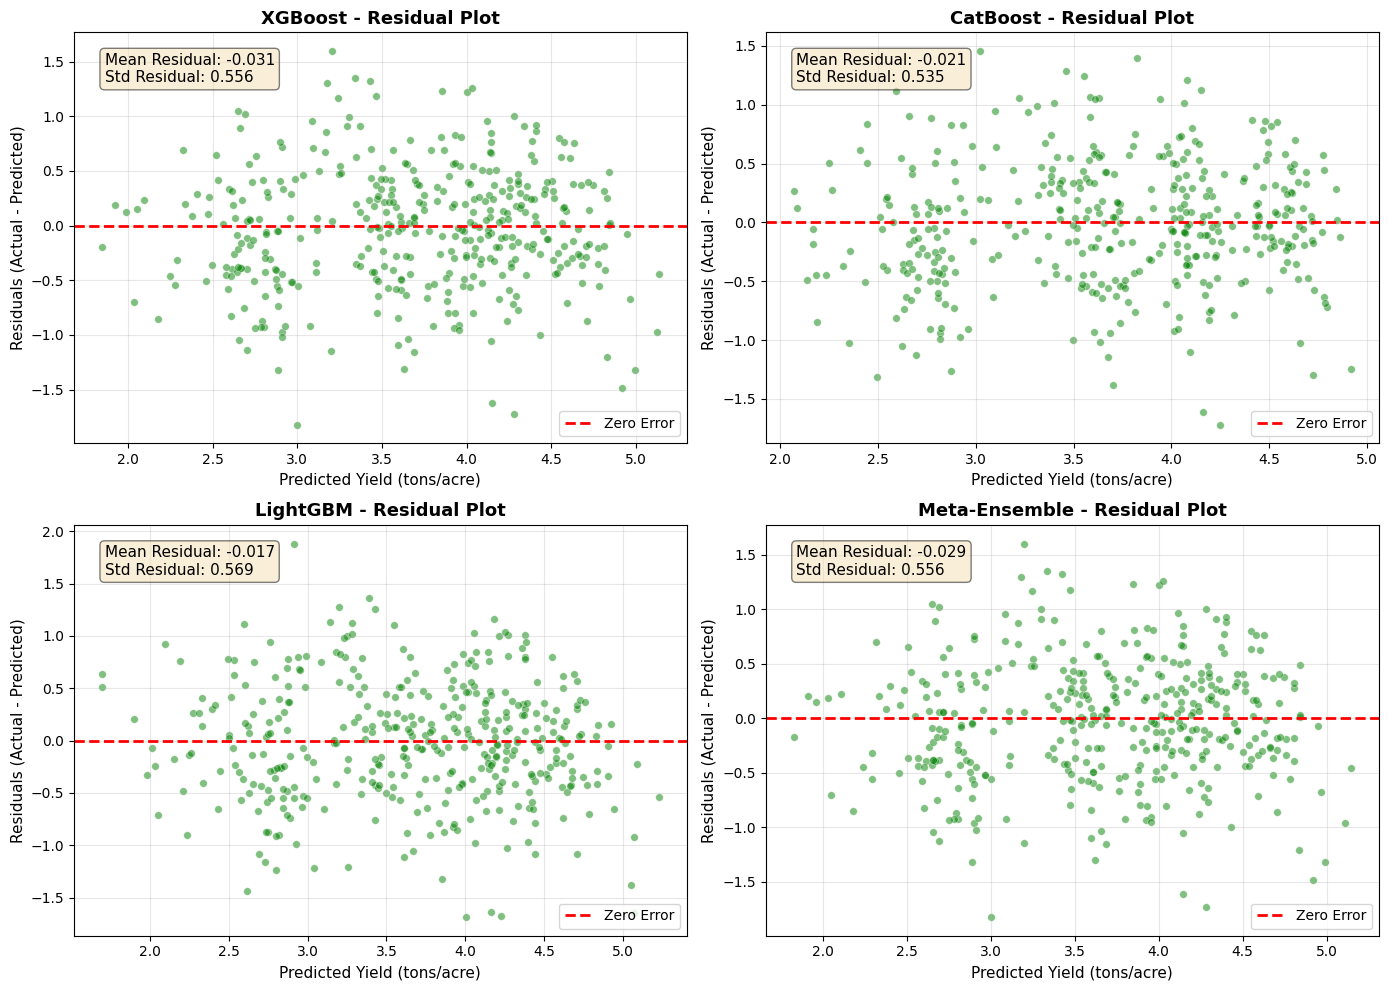

✅ Saved: visualizations/2_residual_plots.png

📊 Creating error distribution histograms...


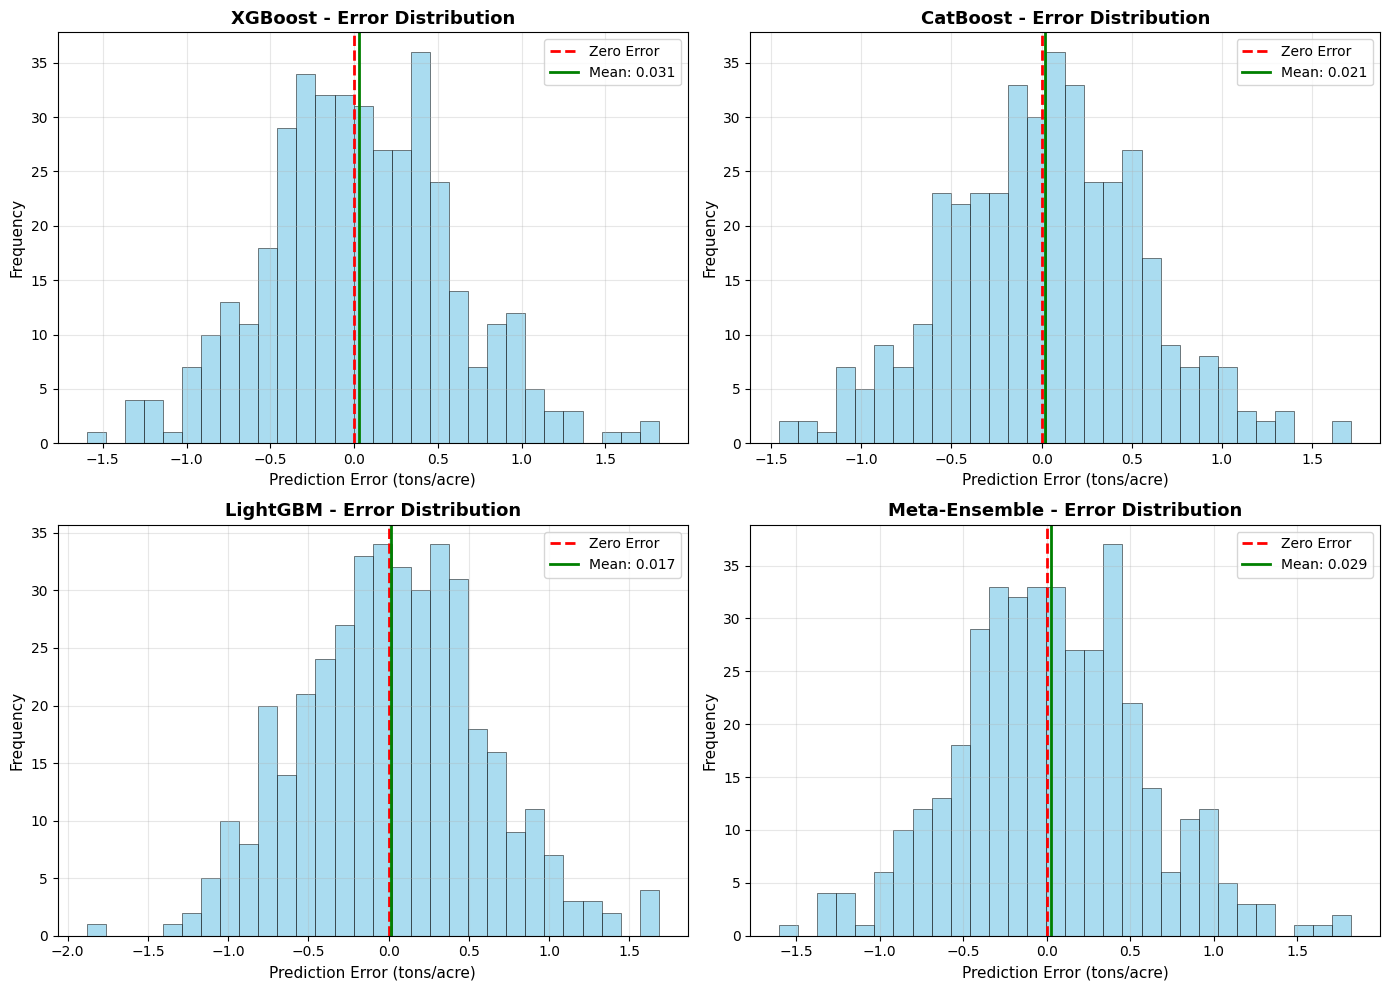

✅ Saved: visualizations/3_error_distribution.png

📊 Creating model comparison bar chart...


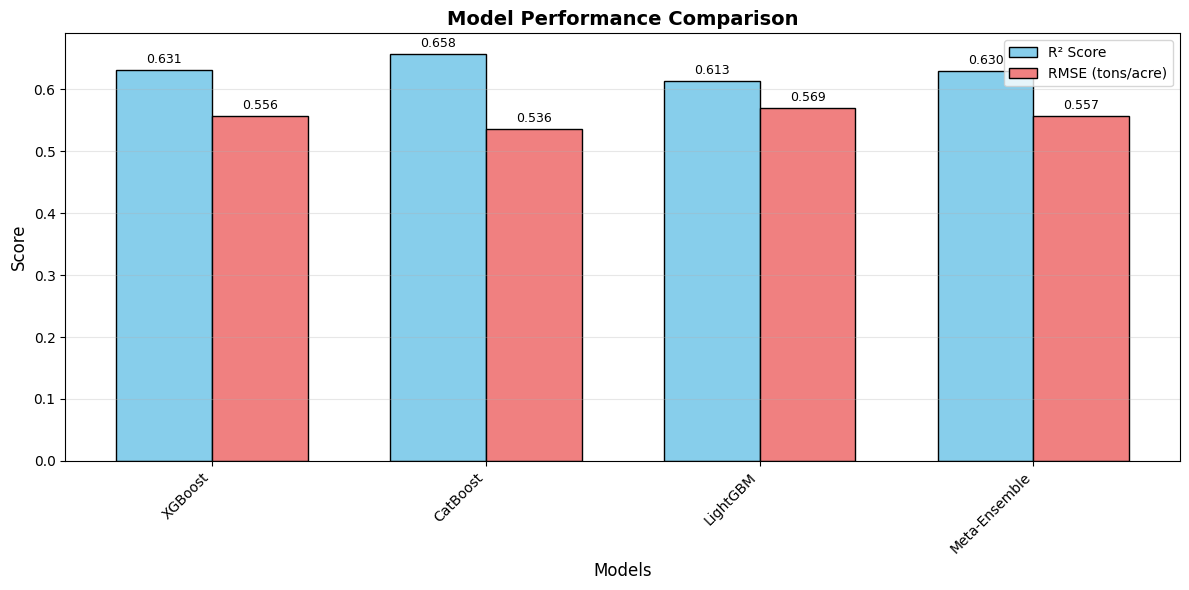

✅ Saved: visualizations/4_model_comparison.png

📊 Creating feature importance plot...


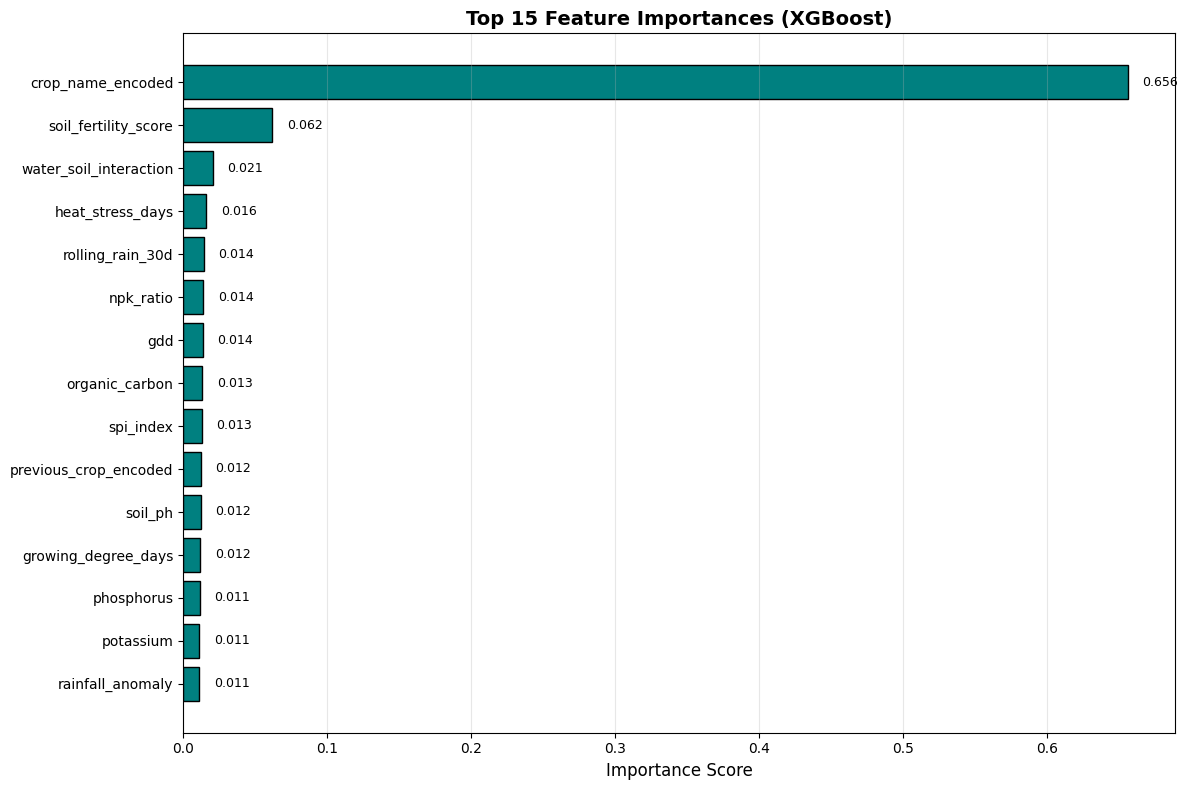

✅ Saved: visualizations/5_feature_importance.png

📊 Creating prediction error box plot...


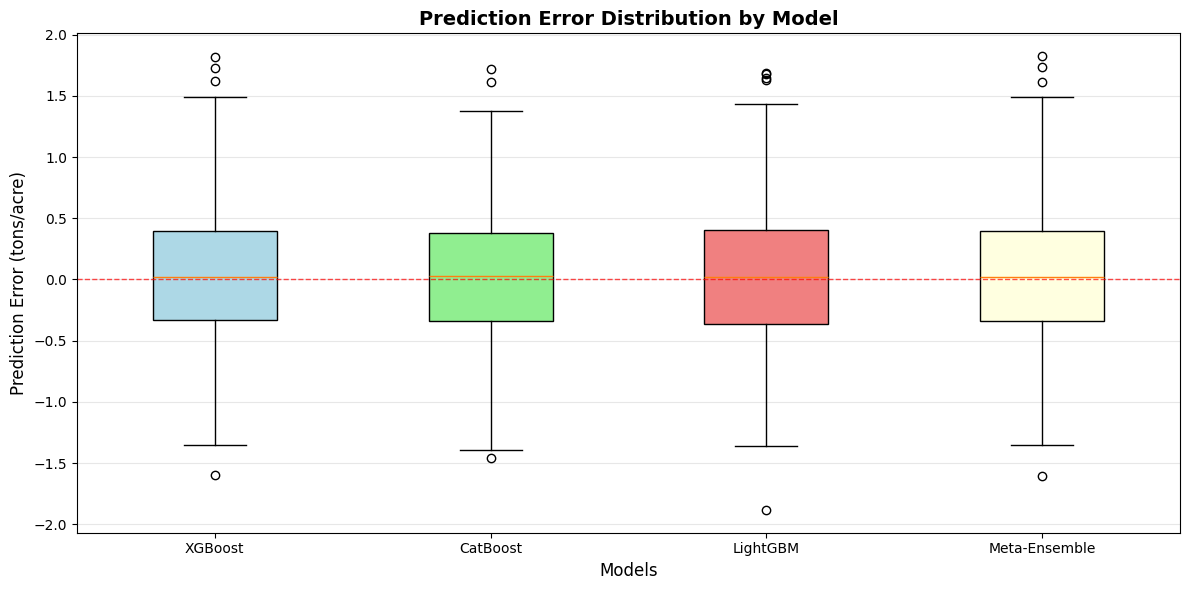

✅ Saved: visualizations/6_error_boxplot.png

🔥 Creating error heatmap (regression confusion matrix)...


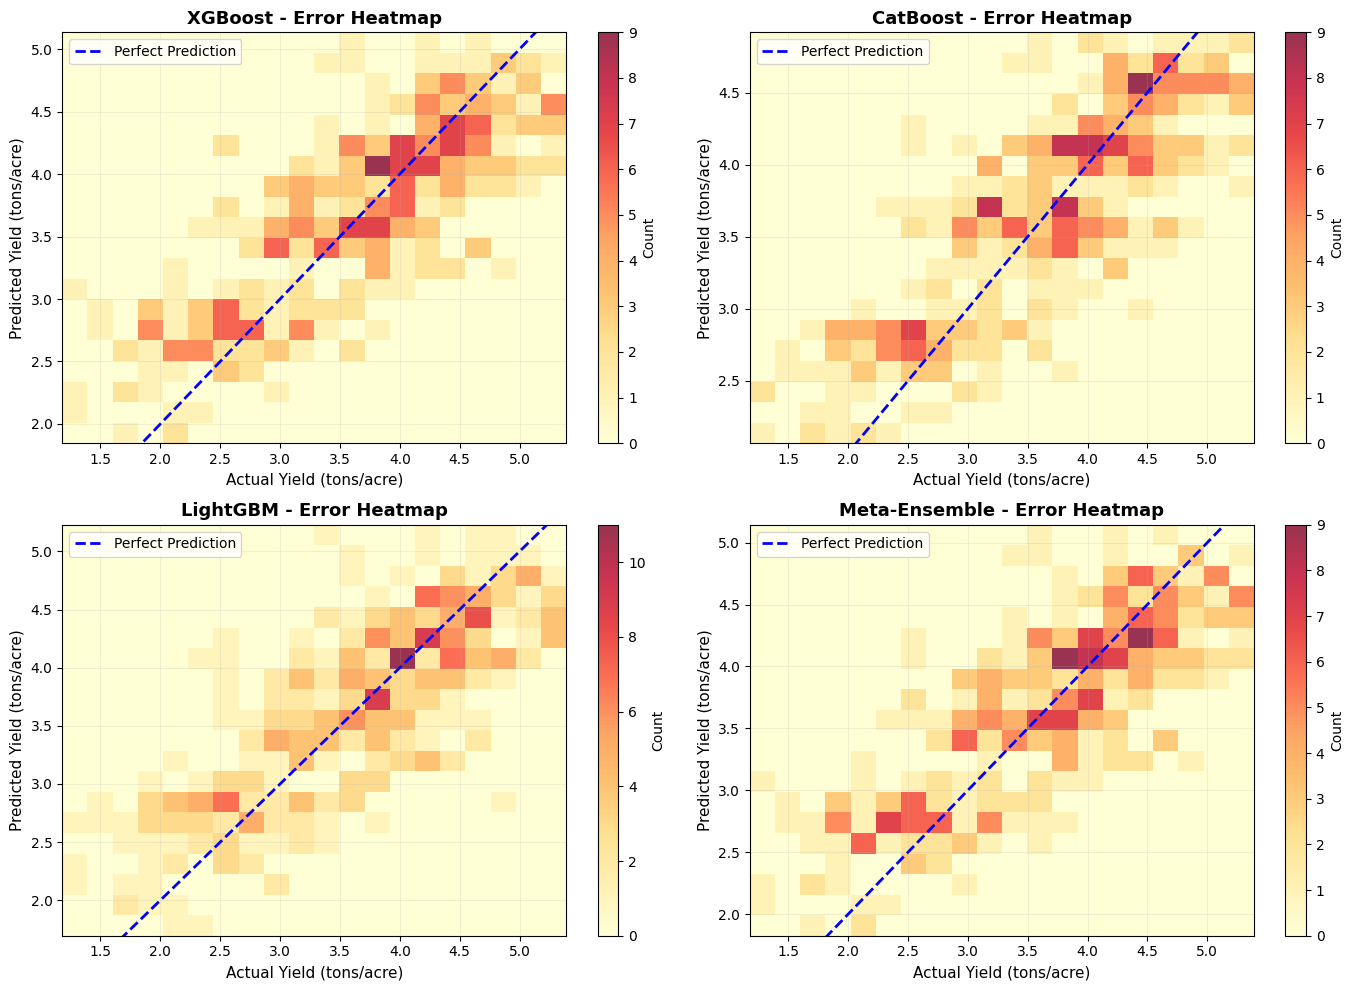

✅ Saved: visualizations/7_error_heatmap.png

📊 Creating metrics summary table...


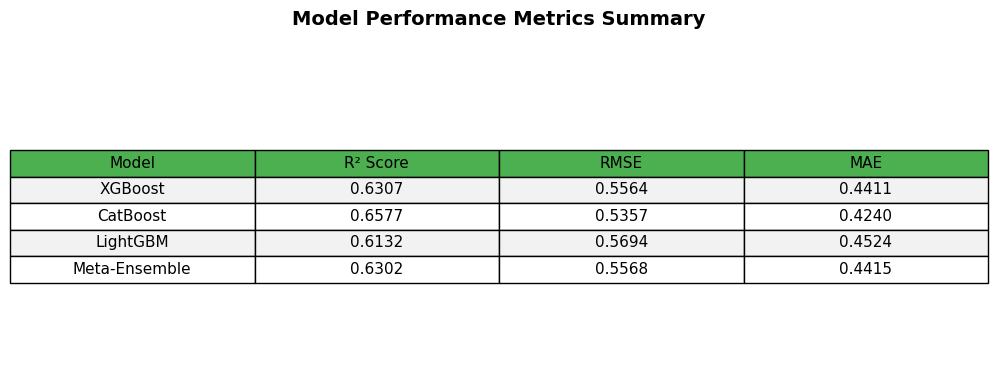

✅ Saved: visualizations/8_metrics_table.png

✅ VISUALIZATIONS GENERATED SUCCESSFULLY

📁 All visualizations saved to: 'visualizations/'

📊 Files created:
   1. visualizations/1_actual_vs_predicted.png - Actual vs Predicted scatter plots
   2. visualizations/2_residual_plots.png - Residual analysis plots
   3. visualizations/3_error_distribution.png - Error histograms
   4. visualizations/4_model_comparison.png - Model performance comparison
   5. visualizations/5_feature_importance.png - Feature importance chart
   6. visualizations/6_error_boxplot.png - Error distribution box plots
   7. visualizations/7_error_heatmap.png - Error heatmaps (regression confusion matrix)
   8. visualizations/8_metrics_table.png - Metrics summary table

🏆 Best Model: CatBoost with R² = 0.6577

💡 Recommendation: Use CatBoost as your primary model!


({'XGBoost': {'R²': 0.6307149354079653,
   'RMSE': np.float64(0.5564059002427667),
   'MAE': 0.4410936246156693},
  'CatBoost': {'R²': 0.657748991996383,
   'RMSE': np.float64(0.5356526070244485),
   'MAE': 0.42401427863836516},
  'LightGBM': {'R²': 0.6132086804378949,
   'RMSE': np.float64(0.5694416309343711),
   'MAE': 0.4524098734181892},
  'Meta-Ensemble': {'R²': 0.6302207537768305,
   'RMSE': np.float64(0.5567780702445704),
   'MAE': 0.44147344865798954}},
 {'XGBoost': array([3.5099676, 2.825164 , 4.1895747, 4.9916663, 3.6481104, 4.62711  ,
         3.9558856, 4.7061353, 2.0541553, 3.552816 , 3.7465062, 3.2029357,
         4.038271 , 2.809818 , 3.6343987, 4.0446887, 4.674996 , 3.0775127,
         3.369561 , 4.206975 , 4.338823 , 4.3463364, 4.347686 , 4.2603354,
         2.6914067, 2.9089477, 4.7759027, 3.6600716, 3.7422705, 3.3445113,
         4.3579097, 3.4847553, 4.2104607, 3.6870992, 4.07146  , 3.0064757,
         3.8917103, 4.3135533, 4.771938 , 4.200928 , 3.7079604, 4.394955 

In [42]:
generate_model_visualizations()